INTRO

---


**Data** : Water Potability. Pengujian kelayakan air
minum

**Latar Belakang** : Suatu perusahaan ingin melakukan sebuah otomasi untuk menentukan kelayakan air minum secara real-time

**Tujuan** : Memprediksi kelayakan air minum dan meminimalisir risiko distribusi terkontaminasi

In [ ]:
#MENGUMPULKAN DATA
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/water_potability.csv')
df.head()

Mounted at /content/drive


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
#MENELAAH DATA
#cek baris dan kolom
df.shape
#cek informasi data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
#CEK NILAI UNIK
for col in df.columns :
  print (f"nilai unik {col} {df[col].unique()}")

nilai unik ph [       nan 3.71608008 8.09912419 ... 9.41951032 5.12676292 7.87467136]
nilai unik Hardness [204.89045547 129.42292051 224.23625939 ... 175.7626463  230.60375751
 195.10229859]
nilai unik Solids [20791.31898075 18630.05785797 19909.54173229 ... 33155.57821831
 11983.86937634 17404.17706105]
nilai unik Chloramines [7.30021187 6.63524588 9.2758836  ... 7.35023323 6.30335653 7.50930586]
nilai unik Sulfate [368.51644135          nan 356.88613564 ... 258.93060041 345.70025734
 359.94857437]
nilai unik Conductivity [564.30865417 592.88535913 418.60621306 ... 432.04478305 402.88311312
 327.45976046]
nilai unik Organic_carbon [10.37978308 15.18001312 16.86863693 ... 11.03906969 11.16894622
 16.14036763]
nilai unik Trihalomethanes [86.99097046 56.32907628 66.42009251 ... 69.84540029 77.4882131
 78.69844633]
nilai unik Turbidity [2.96313538 4.50065627 3.05593375 ... 3.2988755  4.70865847 2.30914906]
nilai unik Potability [0 1]


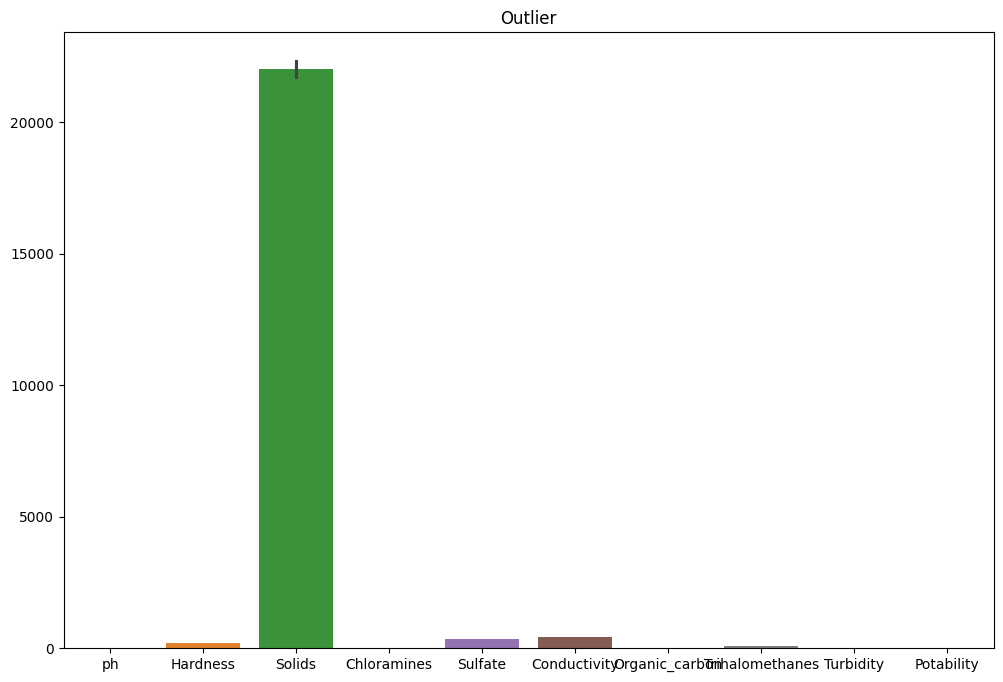

In [ ]:
#CEK OUTLIER
import matplotlib.pyplot as plt
import seaborn as sns
#Target Cek numeric data
numeric_cols = df.select_dtypes(include=['float64','int64']).columns

#Visual dengan Barplot
plt.figure(figsize=(12,8))
sns.barplot(df[numeric_cols])
plt.title('Outlier')
plt.show()

In [ ]:
#CLEANING
#Missing Value
df.isna().sum().sort_values(ascending=False)

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


In [ ]:
#IMPUTASI MEAN ke missing value
missing_val = ['Sulfate', 'ph', 'Trihalomethanes']

for col in missing_val:
  df[col].fillna(df[col].mean(), inplace=True)

/tmp/ipykernel_954/2690761785.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)


In [ ]:
#cek lagi
df.isnull().sum()

,0
ph,0
Hardness,0
Solids,0
Chloramines,0
Sulfate,0
Conductivity,0
Organic_carbon,0
Trihalomethanes,0
Turbidity,0
Potability,0


Potability
0    1998
1    1278
Name: count, dtype: int64


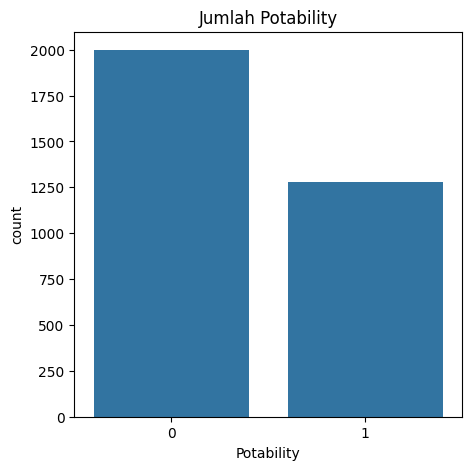

In [ ]:
#CEK DISTRIBUSI TARGET DATA (Potability)
#jumlah nilai potability 0 / 1
print (df['Potability'].value_counts())
#Visualisasi
plt.figure(figsize=(5,5))
sns.countplot(x='Potability', data=df)
plt.title('Jumlah Potability')
plt.show()


In [ ]:
#OVERSAMPLING dengan SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

#pisahkan fitur dan target
X = df.drop('Potability', axis=1)
y = df['Potability']

#Split Train dan Test 80:20
X_train,X_test,y_train,y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#terapkan SMOTE pada Train
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#distribusi
print("SEBELUM :", y_train.value_counts().to_dict())
print("SESUDAH :", y_train_resampled.value_counts().to_dict())

SEBELUM : {0: 1598, 1: 1022}
SESUDAH : {0: 1598, 1: 1598}


Potability
0    1598
1    1598
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

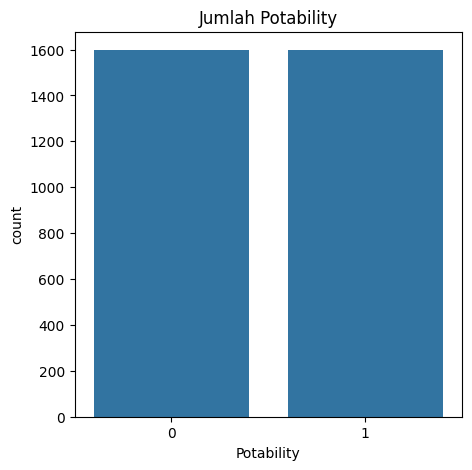

In [ ]:
#VISUALKAN
#Buat dataframe baru
df_resampled = pd.DataFrame(X_train_resampled, columns=X_train.columns)
df_resampled['Potability'] = y_train_resampled
#Sesudah
print(df_resampled['Potability'].value_counts())
plt.figure(figsize=(5,5))
sns.countplot(x='Potability', data=df_resampled)
plt.title('Jumlah Potability')
plt.show

In [ ]:
#cek duplikasi dan nilai kosong
print(df_resampled.duplicated().sum())
print(df_resampled.isnull().sum())

#cek konstruksi data
df_resampled.shape
df_resampled.info()

0
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3196 entries, 0 to 3195
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3196 non-null   float64
 1   Hardness         3196 non-null   float64
 2   Solids           3196 non-null   float64
 3   Chloramines      3196 non-null   float64
 4   Sulfate          3196 non-null   float64
 5   Conductivity     3196 non-null   float64
 6   Organic_carbon   3196 non-null   float64
 7   Trihalomethanes  3196 non-null   float64
 8   Turbidity        3196 non-null   float64
 9   Potability       3196 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 249.8 KB


In [ ]:
df_resampled.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.822492,208.636720,22308.821729,5.850328,408.123255,502.789396,16.135732,60.393982,3.835332,0
1,6.037428,227.033994,12988.791229,8.476905,392.380529,306.386283,7.122391,41.190507,3.594217,1
2,8.445219,228.522860,28966.569327,6.179855,333.775777,361.705354,14.554220,60.612230,4.400706,0
3,6.745307,218.424637,21871.838700,7.165509,333.775777,373.050102,16.826619,74.086080,3.902353,0
4,6.506488,202.285938,17087.076902,6.201983,326.662368,481.771934,16.535186,46.205748,3.548776,0


In [ ]:
df_resampled.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3196.000000,3196.000000,3196.000000,3196.000000,3196.000000,3196.000000,3196.000000,3196.000000,3196.000000,3196.000000
mean,7.082408,196.896512,21968.956267,7.114255,334.211915,428.644267,14.258747,66.097749,3.970634,0.500000
std,1.406565,31.893691,8894.516656,1.558369,35.912772,79.085807,3.185781,15.312019,0.756621,0.500078
min,0.227499,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.492207,0.000000
25%,6.322800,177.880845,15416.923663,6.137411,317.301602,370.066708,12.163066,56.730267,3.454545,0.000000
50%,7.080795,197.298169,20903.152580,7.106531,333.775777,425.780047,14.189459,66.396293,3.977118,0.500000
75%,7.815817,216.458873,27203.707180,8.100396,351.229039,484.034462,16.384701,75.669421,4.477081,1.000000
max,13.541240,323.124000,61227.196008,13.043806,481.030642,753.342620,27.006707,124.000000,6.739000,1.000000


In [ ]:
#PEMODELAN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import xgboost as xgb
import pandas as pd

#Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

#Inisialisasi model
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='logloss')
}

#Training & Evaluasi
result = []
for name, model in models.items():
  #scaled untuk logistic regression
  if name == 'Logistic Regression':
    model.fit(X_train_scaled, y_train_resampled)
    y_pred = model.predict(X_test_scaled)
  else:
    model.fit(X_train_resampled, y_train_resampled)
    y_pred = model.predict(X_test)

#Metrik
  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)

#simpan hasil
  result.append({
      'Model': name,
      'Accuracy': acc,
      'Precision': prec,
      'Recall': rec,
      'F1-Score': f1
  })

#menampilkan perbandingan dalam DF
df_result = pd.DataFrame(result)
print(df_result)



                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.521341   0.407643  0.500000  0.449123
1        Random Forest  0.650915   0.563981  0.464844  0.509636
2              XGBoost  0.623476   0.517510  0.519531  0.518519


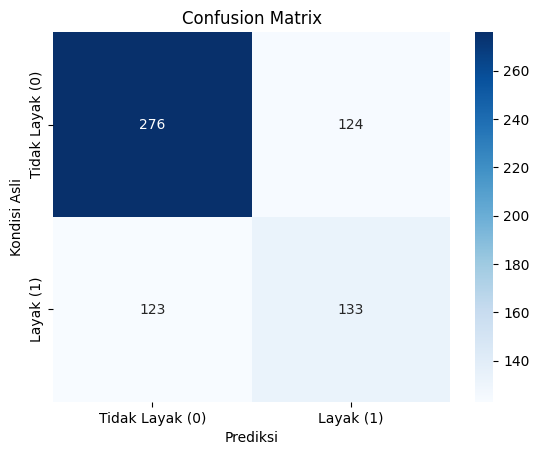

In [ ]:
#VISUALISASI
import seaborn as sns
import matplotlib.pyplot as plt

#dipilih XGBoost karena f1score, recall, precision seimbang
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train_resampled, y_train_resampled)
y_pred_best = model.predict(X_test)

#Visual Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels = ['Tidak Layak (0)', 'Layak (1)'],
            yticklabels = ['Tidak Layak (0)', 'Layak (1)'])
plt.xlabel('Prediksi')
plt.ylabel('Kondisi Asli')
plt.title('Confusion Matrix')
plt.show()


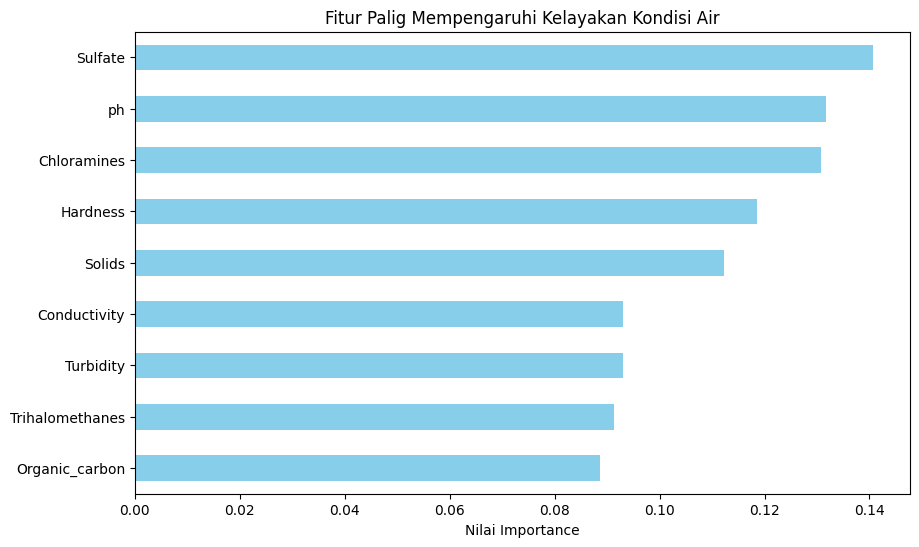

In [ ]:
importances = pd.Series(model.feature_importances_, index=X_train_resampled.columns)
importances.sort_values().plot(kind='barh', figsize = (10,6), color = 'skyblue')
plt.title('Fitur Palig Mempengaruhi Kelayakan Kondisi Air')
plt.xlabel('Nilai Importance')
plt.show()

**KESIMPULAN**

---

**Performa Model**

Dipilih XGBoost sebagai model terbaik akrena kombinasi metrik antara Accuracy, Precision, Recall, dan F1-Score paling seimbang.

SMOTE  digunakan untu menangani class imbalance dan mencegah model menjadi terbias ke arah salah satu mayoritas data.

**Evaluasi Confussion Matrix**

Model XGBoost berhasil memprediksi sampel air layak (TP) sebanyak 133 dan sampel air tidak layak (TN) sebanyak 276 secara akurat.

Tetapi masih ada kasus dimana ada 124 **False Positive (FP)**. Dalam studi kasus industri aair minum ini, berarti ada angka FP yang mewakili risiko distribusi air terkontaminasi. Oleh karen itu, sistem ini diproyeksikan untuk Early Warning System, bukan sebagai penentu pengawasan laboratorium.

**REKOMENDASI PADA BISNIS & OPERASIONAL**

Berdasarkan Feature Importances, ditemukan bahwa ada tiga kontributor terbesar dalam menentukan kualitas air. Variabelnya yaitu **Sulfate**, **pH**, dan **Chloramines**. Variabel ini bisa menjadi acuan monitoring.

**Melaksanakan Monitoring** : Pihak pengelola disarankan untuk mengalokasikan anggaran sensor otomasi pada parameter **Sulfate** dan **pH** karena ini yang paling berdampak dalam status kelayakan air.

**Filtrasi** : Menentukan ambang batas dan peringatan dini pada sistem jika kadar **Sulfate** atau **pH** diluar batas standar dari WHO sebelum kita melaksanakan prediksi model dengan XGBoost.